# Analysis of global order data  

- Note: All analysis is for a single global order simulation

1. Smooth the data  
2. Calculate Transition Time  
3. Calculate Sync Time  
4. Calculate number of transitions
5. Plot global order vs time with crossing marked

#### Import necessary packages

In [1]:
%reload_ext autoreload
%autoreload 2


from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc
import matplotlib.pyplot as plt

#### Create objects for data_reading and analysis  


In [2]:
reader = DataRead()
analyse = AnalysisFunc()

#### Reading data

In [3]:
df = reader.data_read_bz2('raw/test/itr_test.bz2')

#### 1. Smooth global order data  
Each iteration can be accessed using column index df[0]

In [4]:
n=5
df_smooth = analyse.smooth(df[n])

Plot of global order to check if smooth is fine

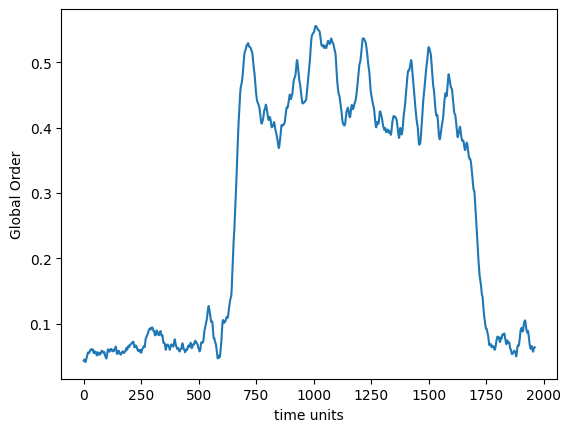

In [5]:
# use get_time function to get time units for X axis
plt.figure(num=1,clear=True)
time = analyse.get_time(df[n], 0.05)
plt.plot(time, df_smooth)
plt.xlabel("time units")
plt.ylabel("Global Order")
plt.show()

#### Calculate 
2. Number of transition  
3. Transition time  
4. Sync time (averaged)


In [6]:
dt = 0.05
a = analyse.trans_state_time(df_smooth, dt)
print(a)

{'num': 1, 'trans_time': [69.15], 'state_time': 1142.05, 'up_cros': [671.8000000000001], 'low_cros': [602.65, 1744.7]}


#### Plot with transition time crossings marked

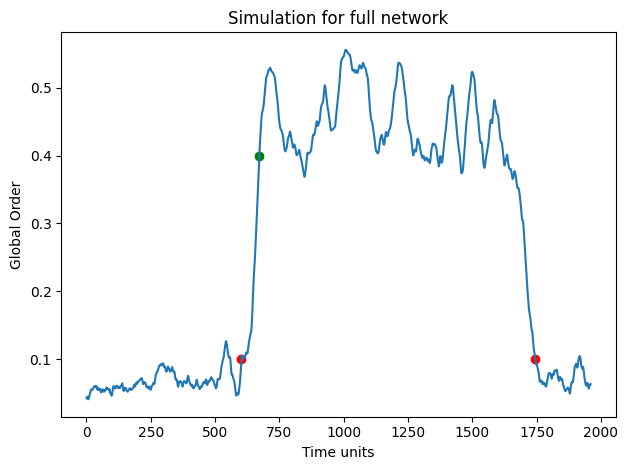

In [10]:
plt.figure(clear=True)
analyse.plot_global_synchrony(df[n],dt)
plt.tight_layout()
plt.show()